In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import pandas as pd
import pyarrow.parquet as pq

path = "../datasets/NF-CSE-CIC-IDS2018-V2.parquet"

# cek label (tetap cepat)
df = pd.read_parquet(path, columns=["Label"])
print(df["Label"].value_counts(normalize=True))

frac = 0.001

parquet_file = pq.ParquetFile(path)

samples = []

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()

    sampled_chunk = (
        chunk
        .groupby("Label", group_keys=False)
        .sample(frac=frac, random_state=42)
    )

    samples.append(sampled_chunk)

df_sample = pd.concat(samples, ignore_index=True)

print("Sample shape:", df_sample.shape)
print(df_sample["Label"].value_counts(normalize=True))

df_sample.to_parquet("../datasets/NF-CSE-CIC-IDS2018-V2_sample.parquet", index=False)

Label
0    0.881607
1    0.118393
Name: proportion, dtype: float64
Sample shape: (17130, 43)
Label
0    0.881611
1    0.118389
Name: proportion, dtype: float64


In [3]:
df_sample.head()

,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,...,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack
0,60804,53,17,0.0,62,1,218,1,0,0,...,0,0,0,0,10361,1,60,0,0,Benign
1,51628,53,17,0.0,62,1,94,1,0,0,...,0,0,0,0,59123,1,60,0,0,Benign
2,62100,53,17,0.0,62,1,78,1,0,0,...,0,0,0,0,49994,1,30,0,0,Benign
3,63196,53,17,0.0,65,1,205,1,0,0,...,0,0,0,0,57043,28,31,0,0,Benign
4,56516,3389,6,0.0,1460,8,1873,7,222,222,...,8192,64000,0,0,0,0,0,0,0,Benign


In [4]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17130 entries, 0 to 17129
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   L4_SRC_PORT                  17130 non-null  int32  
 1   L4_DST_PORT                  17130 non-null  int32  
 2   PROTOCOL                     17130 non-null  int8   
 3   L7_PROTO                     17130 non-null  float32
 4   IN_BYTES                     17130 non-null  int32  
 5   IN_PKTS                      17130 non-null  int32  
 6   OUT_BYTES                    17130 non-null  int32  
 7   OUT_PKTS                     17130 non-null  int32  
 8   TCP_FLAGS                    17130 non-null  int16  
 9   CLIENT_TCP_FLAGS             17130 non-null  int16  
 10  SERVER_TCP_FLAGS             17130 non-null  int16  
 11  FLOW_DURATION_MILLISECONDS   17130 non-null  int32  
 12  DURATION_IN                  17130 non-null  int32  
 13  DURATION_OUT    

In [5]:
df_sample.describe().T

C:\Users\roofi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
L4_SRC_PORT,17130.0,5.295159e+04,1.143938e+04,0.0,50894.0,54579.5,59717.50,6.553400e+04
L4_DST_PORT,17130.0,1.112693e+03,3.342113e+03,0.0,53.0,80.0,445.00,6.512900e+04
PROTOCOL,17130.0,1.097315e+01,5.488244e+00,1.0,6.0,6.0,17.00,5.800000e+01
L7_PROTO,17130.0,1.099414e+01,2.663687e+01,0.0,0.0,0.0,5.63,1.882390e+02
IN_BYTES,17130.0,2.260385e+03,7.995278e+04,40.0,69.0,148.0,1464.00,6.465420e+06
IN_PKTS,17130.0,3.081150e+01,1.332353e+03,1.0,1.0,3.0,9.00,1.077570e+05
OUT_BYTES,17130.0,3.100094e+03,3.795587e+04,0.0,121.0,302.0,1873.00,4.094135e+06
OUT_PKTS,17130.0,7.106947e+00,2.946440e+01,0.0,1.0,3.0,8.00,2.813000e+03
TCP_FLAGS,17130.0,7.373514e+01,9.839571e+01,0.0,0.0,23.0,219.00,2.230000e+02
CLIENT_TCP_FLAGS,17130.0,7.307607e+01,9.819221e+01,0.0,0.0,19.0,219.00,2.230000e+02


In [6]:
df_sample["Label"].value_counts()

Label
0    15102
1     2028
Name: count, dtype: int64

In [7]:
df_sample["Attack"].value_counts()

Attack
Benign                      15102
DDOS attack-HOIC             1060
DoS attacks-Hulk              430
DDoS attacks-LOIC-HTTP        233
Infilteration                 106
SSH-Bruteforce                 83
Bot                            35
DoS attacks-GoldenEye          32
FTP-BruteForce                 26
DoS attacks-SlowHTTPTest       10
DoS attacks-Slowloris           7
DDOS attack-LOIC-UDP            3
Brute Force -XSS                2
Brute Force -Web                1
Name: count, dtype: int64

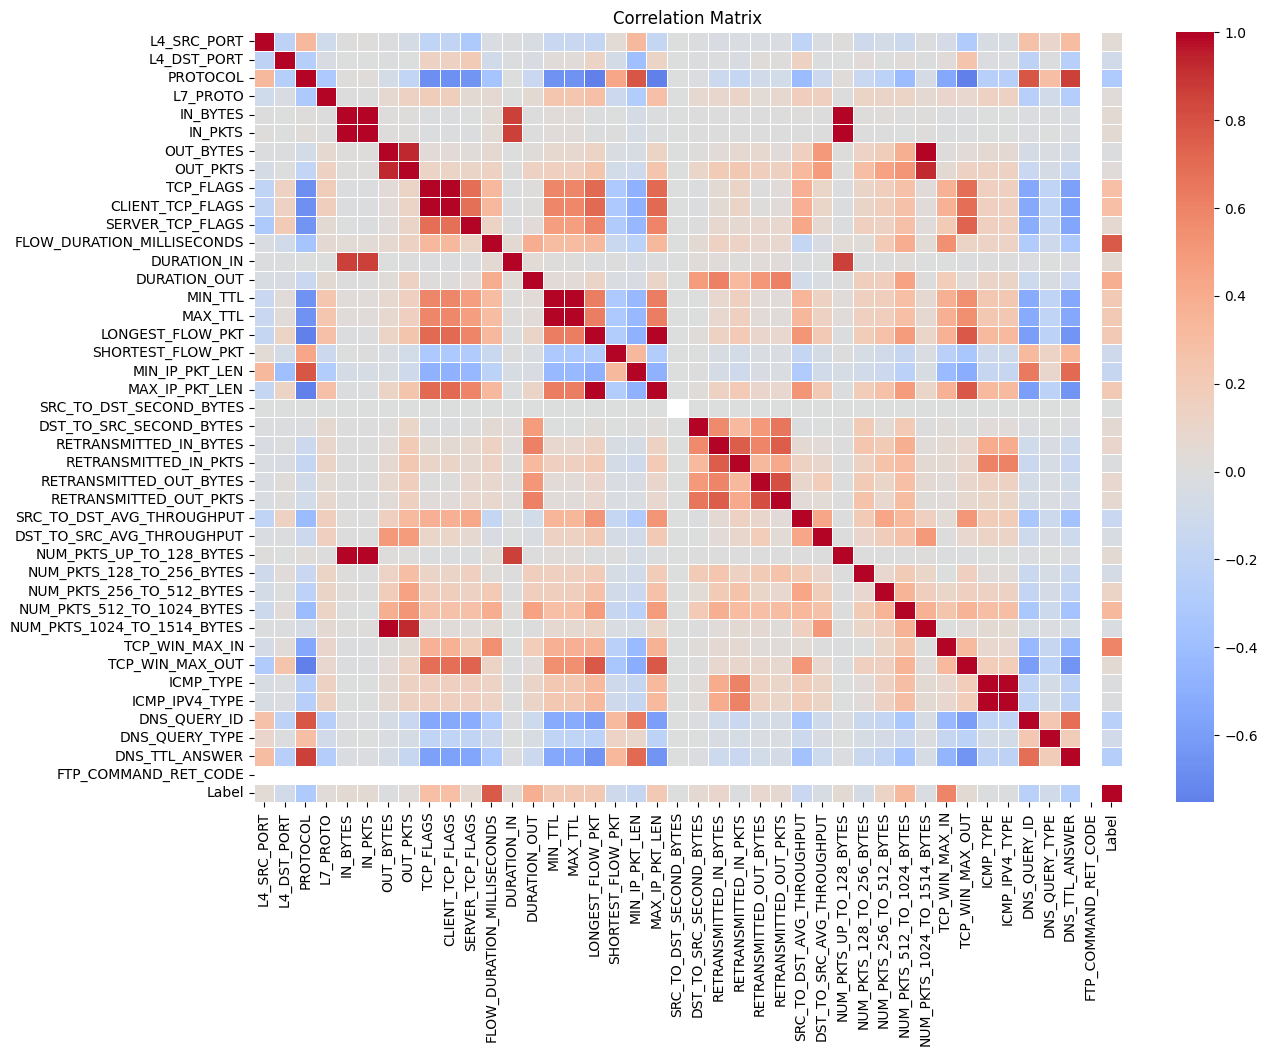

In [8]:
plt.figure(figsize=(14,10))
corr = df_sample.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

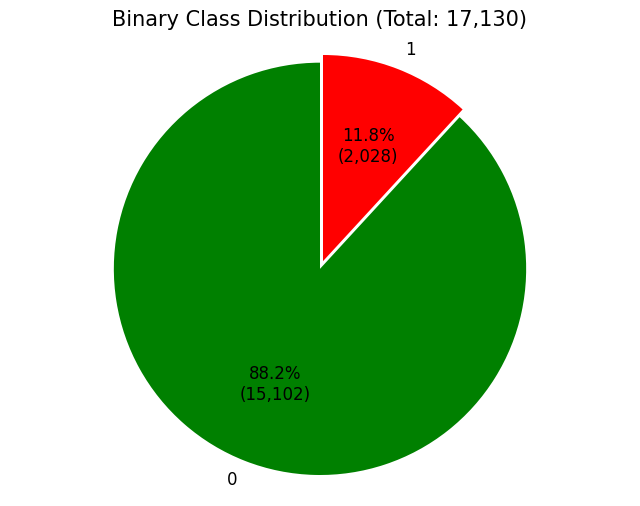

In [9]:
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'
    return inner

# ambil data label
label_counts = df_sample["Label"].value_counts()

labels = label_counts.index.astype(str)
sizes = label_counts.values
colors = ["green", "red"]

plt.figure(figsize=(8, 6))

plt.pie(
    sizes,
    labels=labels,
    autopct=autopct_format(sizes),
    colors=colors,
    startangle=90,
    explode=[0.02] * len(labels),
    textprops={'fontsize': 12}
)

plt.title(f'Binary Class Distribution (Total: {label_counts.sum():,})', fontsize=15)

plt.axis('equal')
plt.show()

In [10]:
numeric_df = df_sample.select_dtypes(include=["int64", "float64"])

corr_with_label = (
    numeric_df
    .corr()["Label"]
    .abs()
    .sort_values(ascending=False)
)

top_features = corr_with_label.index[1:9]
n_cols = 3
n_rows = int(np.ceil(len(top_features) / n_cols))
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(top_features):
    plt.subplot(n_rows, n_cols, i + 1)

    values = df_sample[col]

    if (values > 0).all():
        values = np.log1p(values)
        title = f"{col} (log)"
    else:
        title = col

    sns.kdeplot(
        x=values,
        hue=df_sample["Label"],
        common_norm=False,
        fill=True,
        alpha=0.4
    )

    plt.title(title)

plt.tight_layout()
plt.show()

KeyError: 'Label'

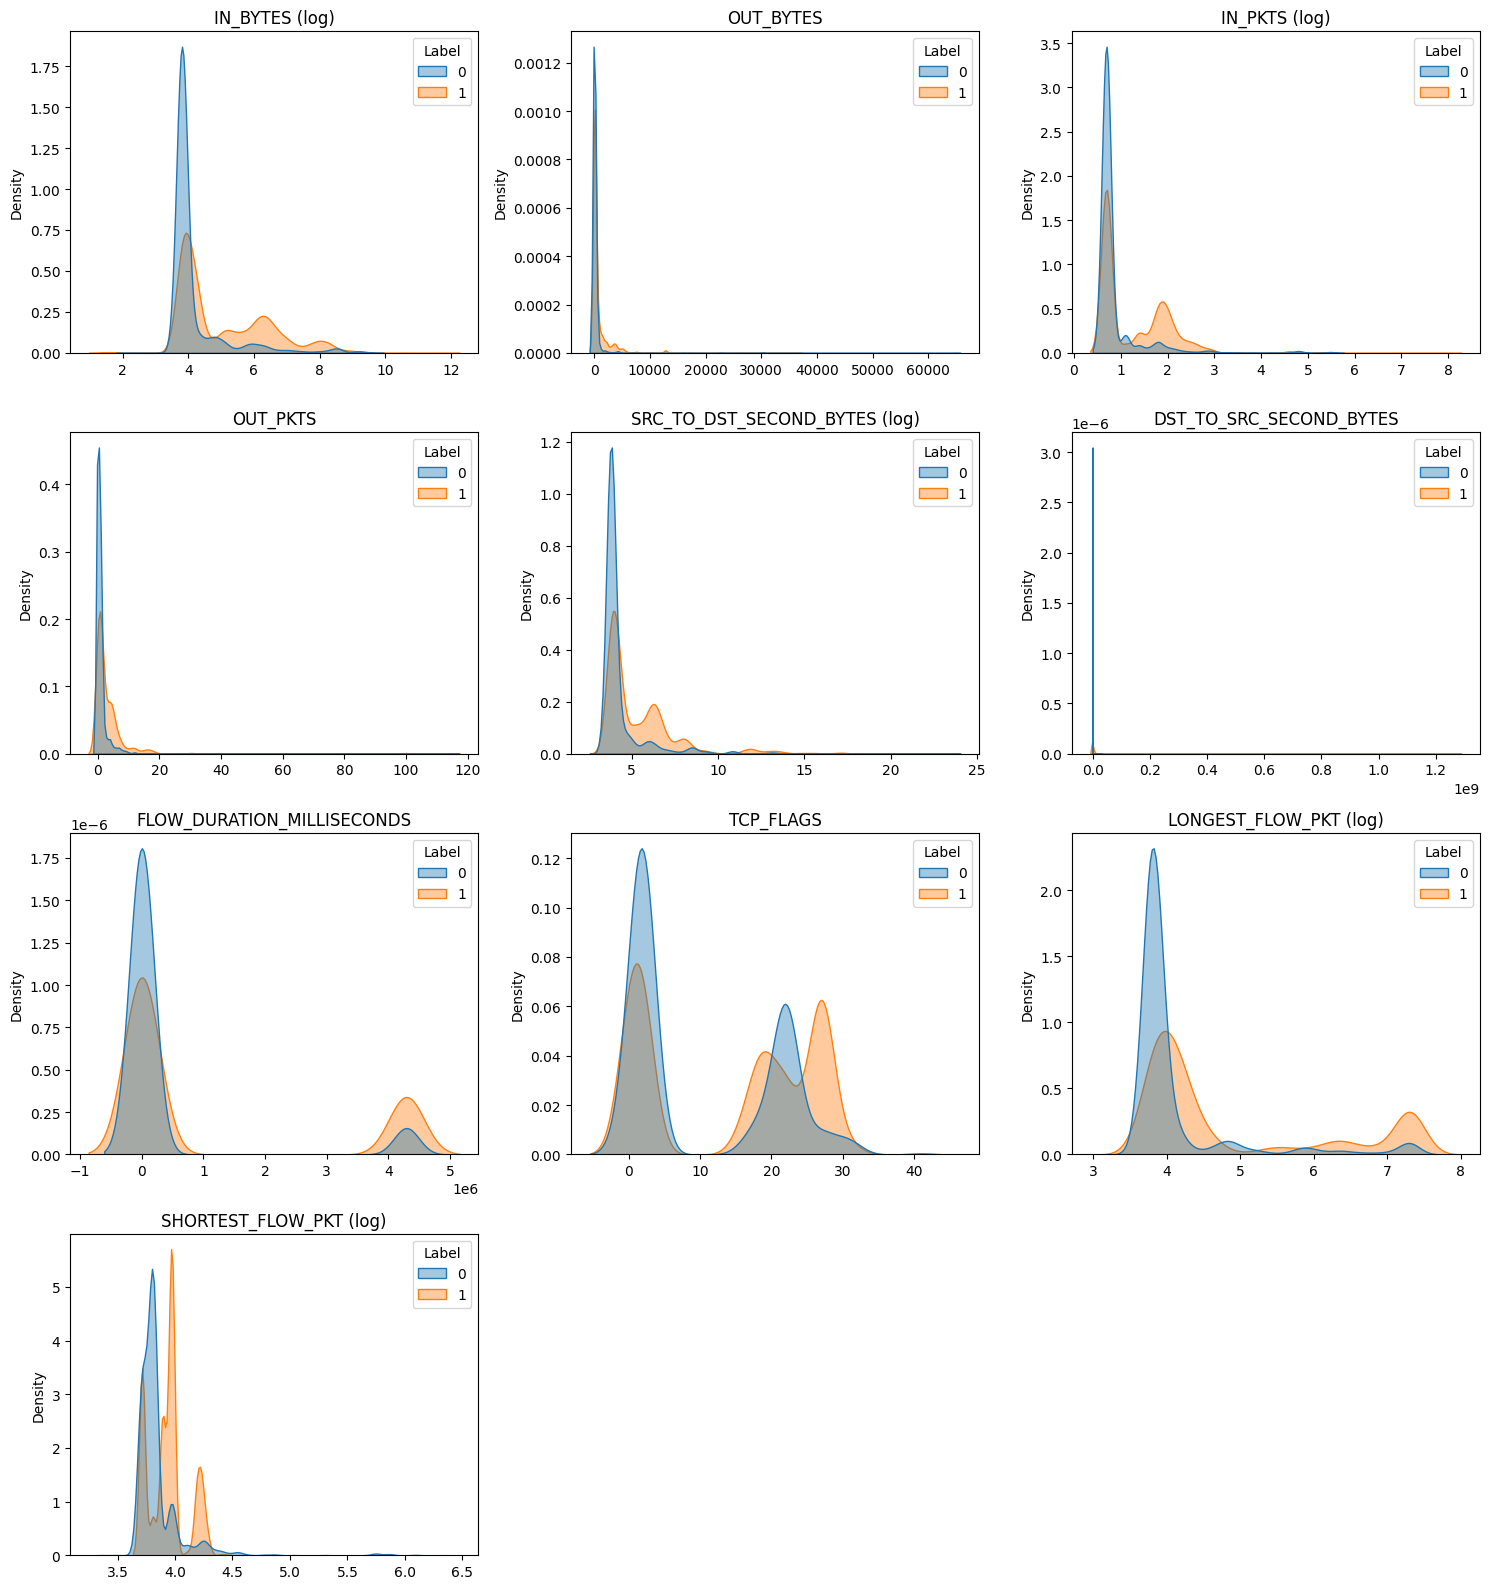

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Top 10 Features You Selected
# ==============================

top_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "FLOW_DURATION_MILLISECONDS",
    "TCP_FLAGS",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT"
]

# Keep only numeric columns
numeric_df = df_sample.select_dtypes(include=["int64", "float64"])

# Clean data
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)
numeric_df.fillna(0, inplace=True)

# ==============================
# Plot Layout
# ==============================

n_cols = 3
n_rows = int(np.ceil(len(top_features) / n_cols))

plt.figure(figsize=(15, 4 * n_rows))

# ==============================
# Plot Loop
# ==============================

for i, col in enumerate(top_features):

    if col not in numeric_df.columns:
        continue

    plt.subplot(n_rows, n_cols, i + 1)

    values = numeric_df[col]

    # Log transform for skewed positive features
    if (values > 0).all():
        values = np.log1p(values)
        title = f"{col} (log)"
    else:
        title = col

    sns.kdeplot(
        x=values,
        hue=df_sample["Label"],
        common_norm=False,
        fill=True,
        alpha=0.4
    )

    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.feature_selection import f_classif

X = numeric_df[top_features]
y = df_sample["Label"]

f_scores, p_values = f_classif(X, y)

anova_df = pd.DataFrame({
    "Feature": top_features,
    "F_score": f_scores,
    "p_value": p_values
})

anova_df = anova_df.sort_values(
    by="F_score",
    ascending=False
)

print(anova_df)


                      Feature      F_score        p_value
8            LONGEST_FLOW_PKT  1070.398396  1.033934e-227
6  FLOW_DURATION_MILLISECONDS   739.735048  1.791491e-159
3                    OUT_PKTS   632.821666  3.960478e-137
7                   TCP_FLAGS   615.722336  1.529537e-133
1                   OUT_BYTES   437.644588   5.748183e-96
0                    IN_BYTES   163.963149   2.296736e-37
9           SHORTEST_FLOW_PKT   130.048535   5.145609e-30
2                     IN_PKTS    18.680490   1.554374e-05
5     DST_TO_SRC_SECOND_BYTES     4.581863   3.232629e-02
4     SRC_TO_DST_SECOND_BYTES     2.434678   1.186970e-01


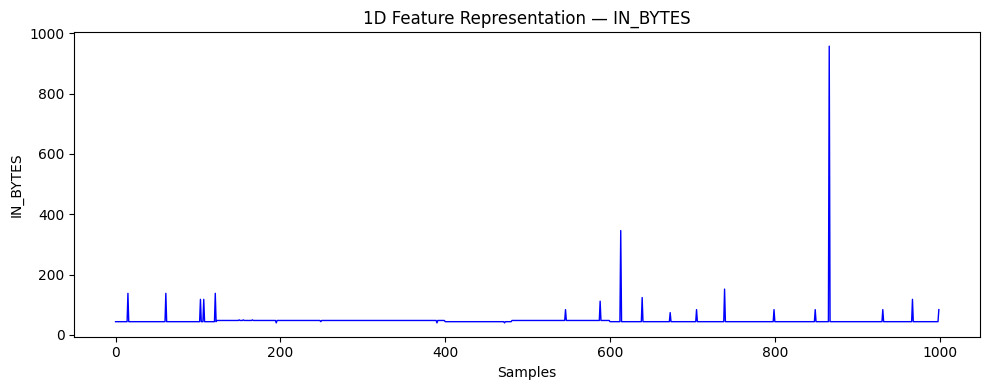

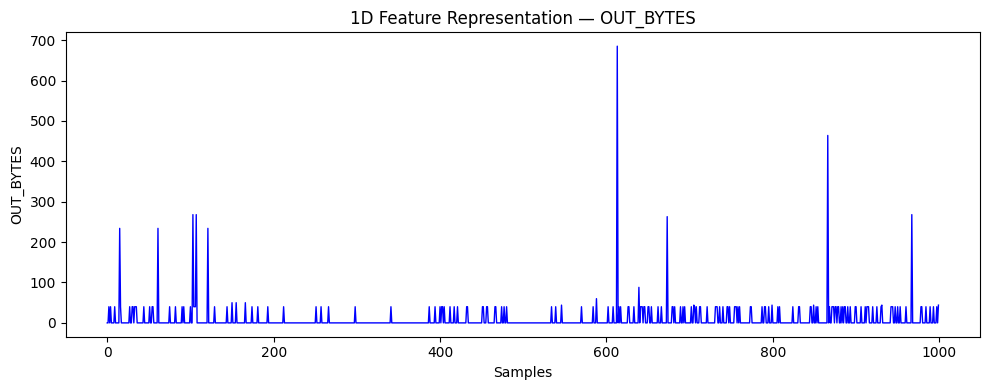

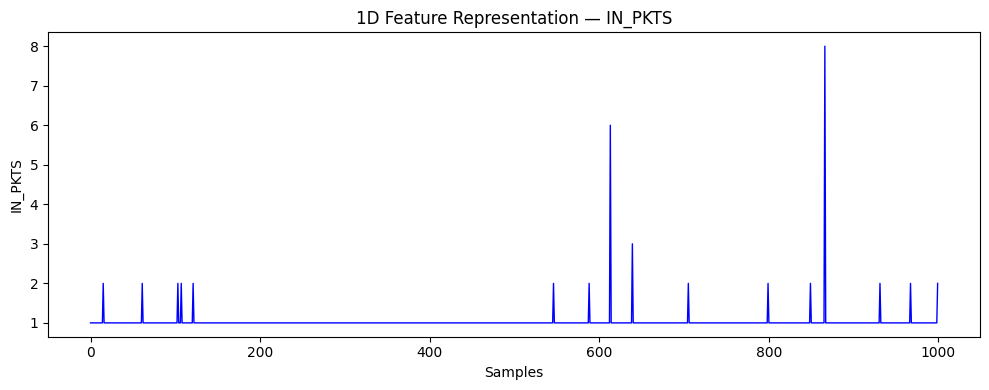

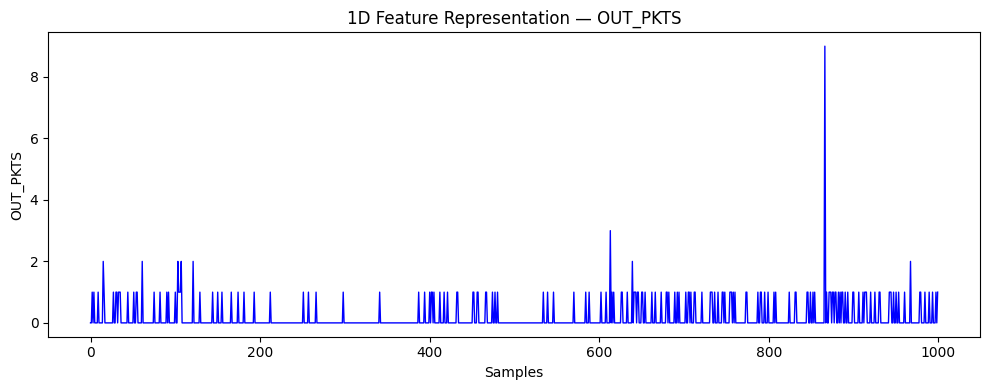

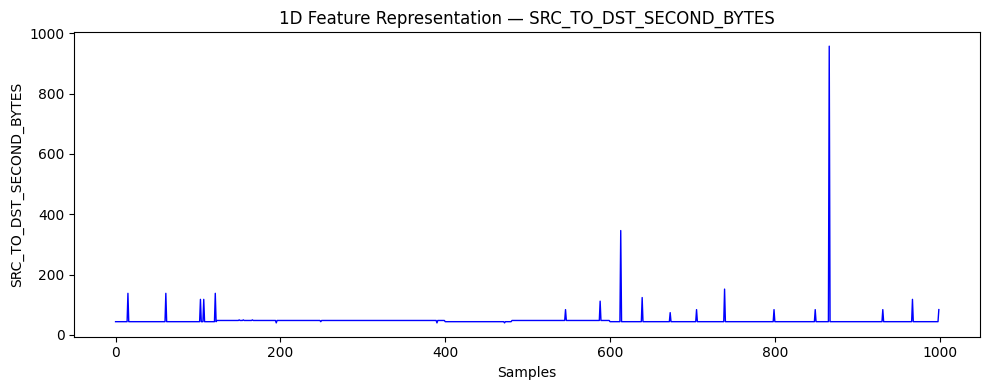

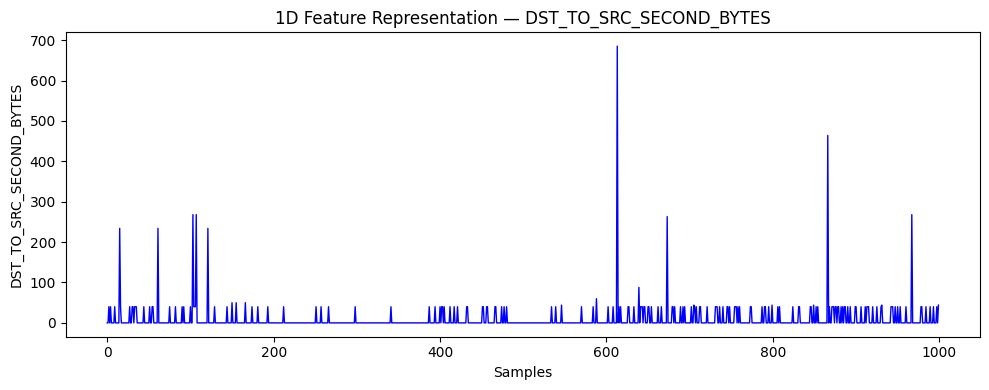

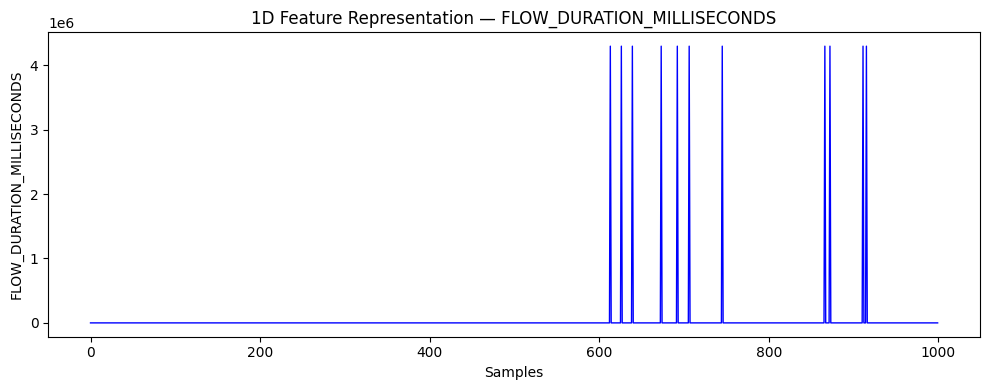

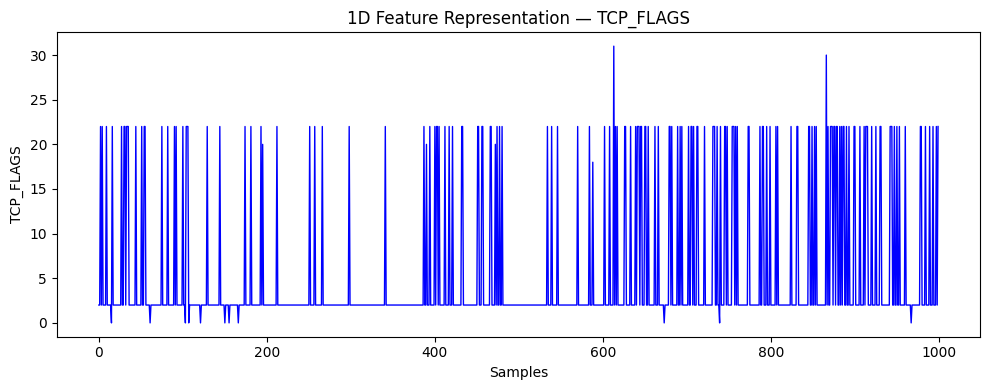

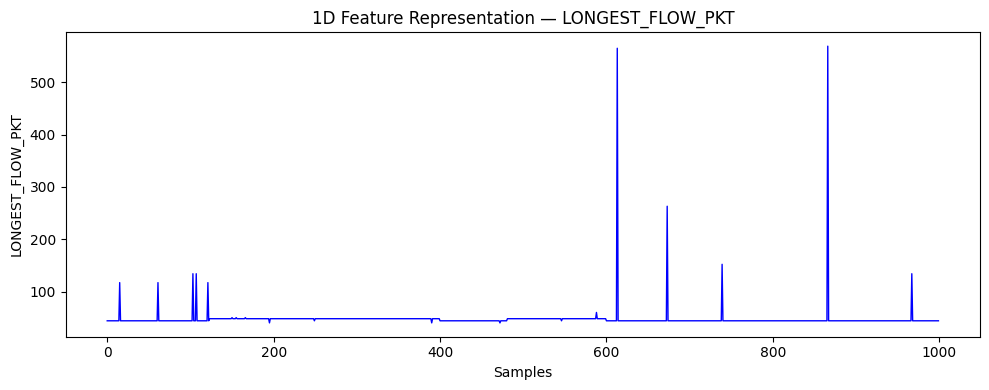

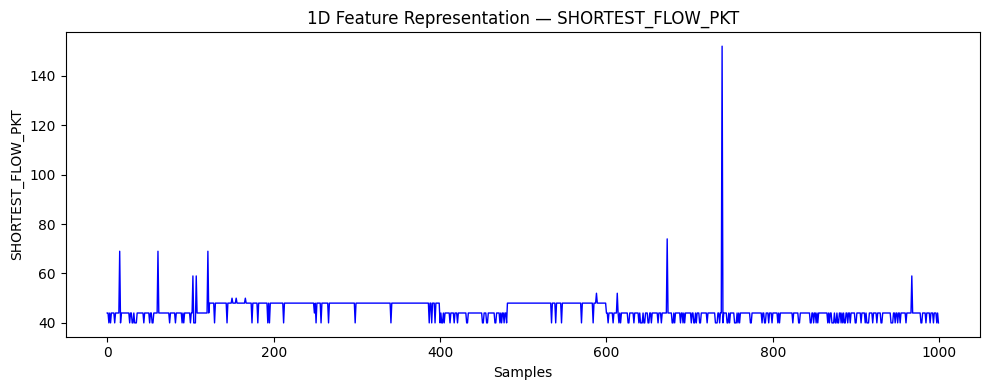

In [ ]:
import matplotlib.pyplot as plt

for col in top_features:

    if col not in numeric_df.columns:
        continue

    plt.figure(figsize=(10,4))

    values = numeric_df[col].values[:1000]  # first 1000 samples

    plt.plot(values, color="blue", linewidth=1)

    plt.title(f"1D Feature Representation — {col}")
    plt.xlabel("Samples")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

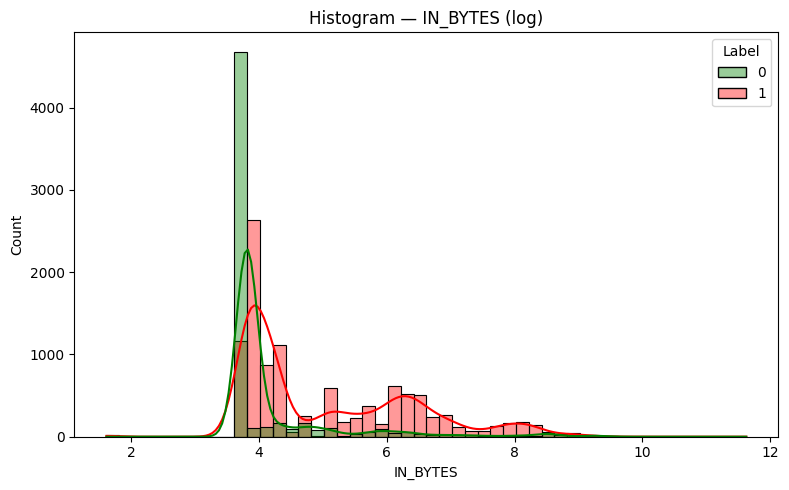

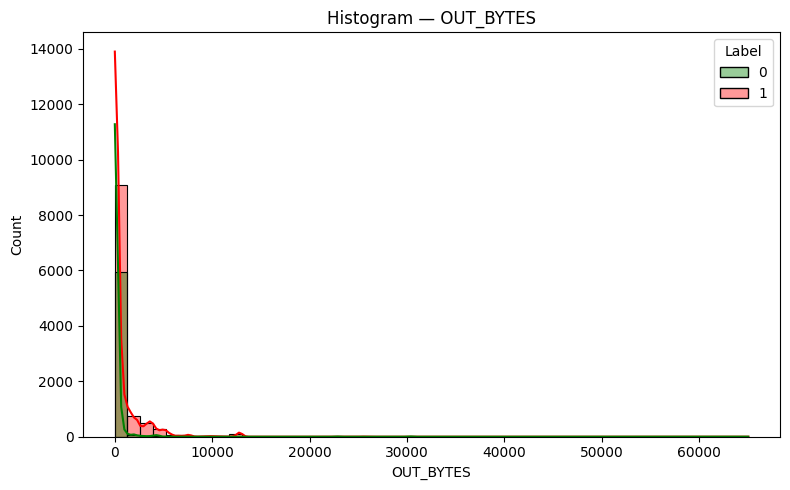

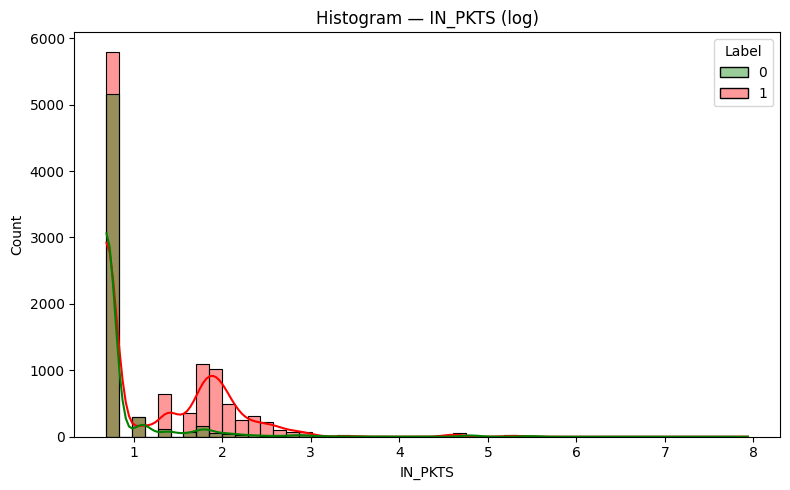

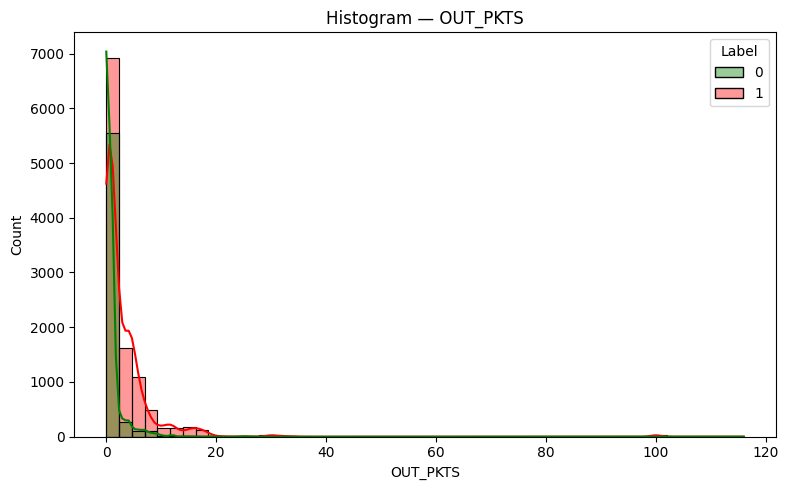

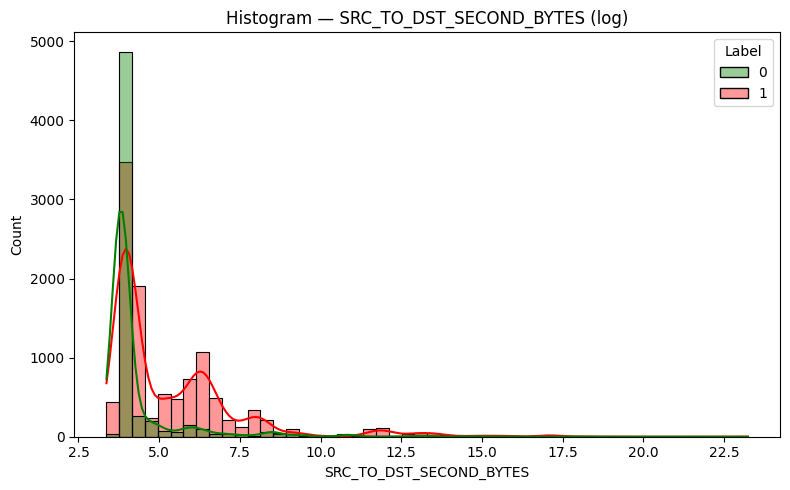

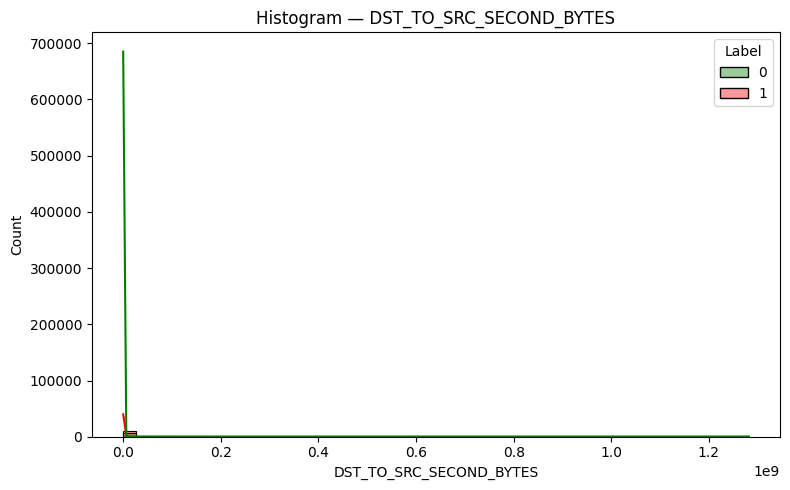

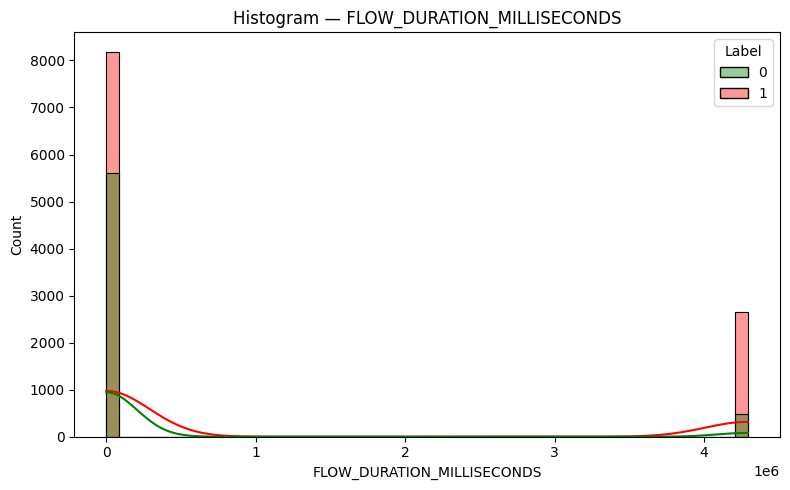

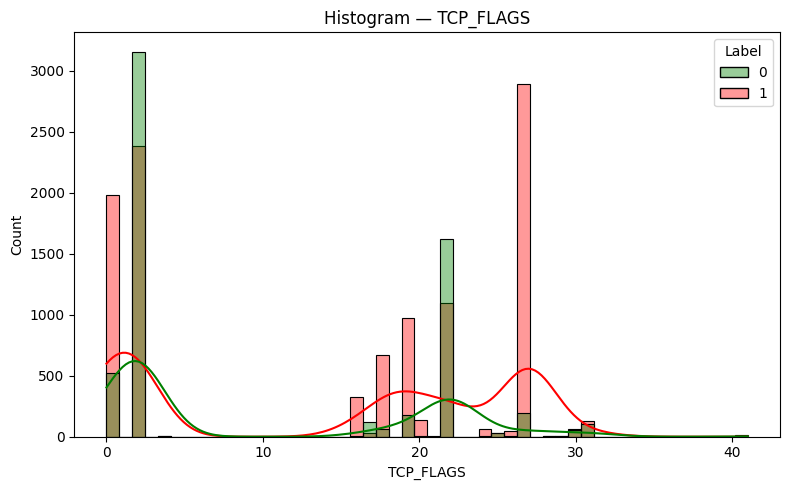

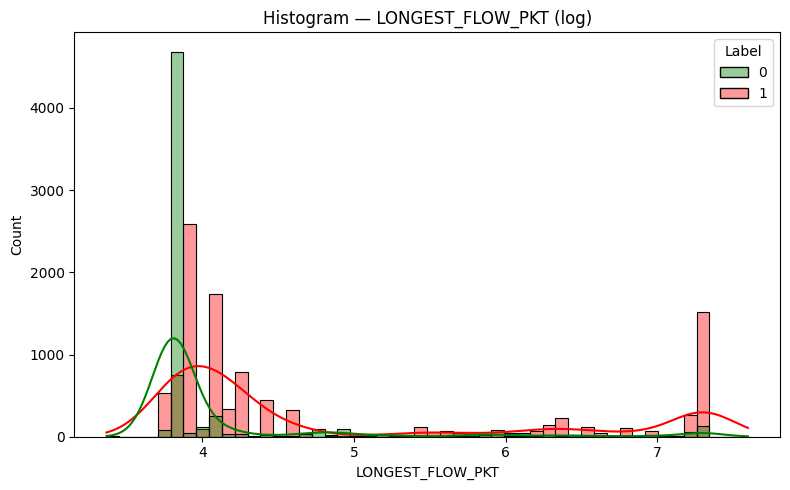

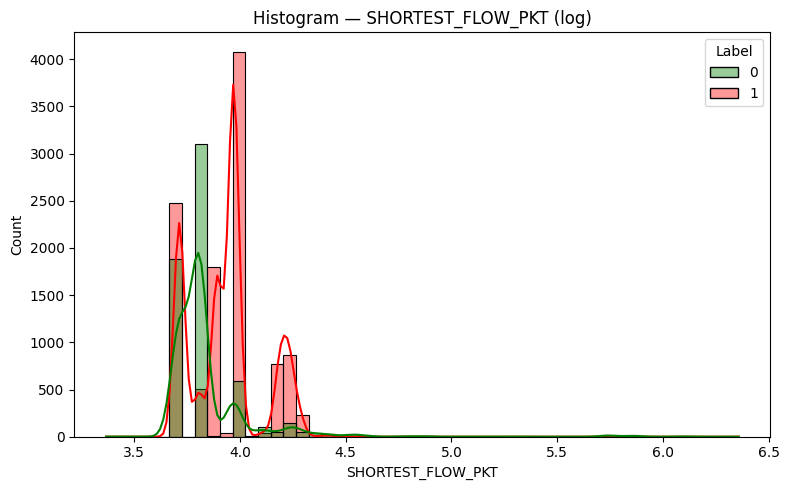

In [ ]:
import seaborn as sns

for col in top_features:

    if col not in numeric_df.columns:
        continue

    plt.figure(figsize=(8,5))

    values = numeric_df[col]

    if (values > 0).all():
        values_plot = np.log1p(values)
        title = f"{col} (log)"
    else:
        values_plot = values
        title = col

    sns.histplot(
        x=values_plot,
        hue=df_sample["Label"],
        bins=50,
        kde=True,
        palette=["green", "red"],
        alpha=0.4
    )

    plt.title(f"Histogram — {title}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()


In [ ]:
top_features = [
    "IN_BYTES",
    "OUT_BYTES",
    "IN_PKTS",
    "OUT_PKTS",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "FLOW_DURATION_MILLISECONDS",
    "TCP_FLAGS",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT"
]
